In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

In [27]:
df = pd.read_csv('data/cleaned_data.csv')
df

,patient_name,age,gender,condition,medication,visit_date,cholesterol,systolic,diastolic,visit_year,visit_month
0,donna hall,51,female,Diabetes,ATORVASTATIN,2021-06-19,207.7,143.0,90.0,2021,6
1,mark young,49,male,Diabetes,METFORMIN,2020-04-06,206.3,109.0,86.0,2020,4
2,lisa young,49,male,Hypertension,NONE,2018-05-23,207.5,153.0,95.0,2018,5
3,daniel robinson,46,male,Asthma,ALBUTEROL,2022-10-10,203.6,127.0,79.0,2022,10
4,robert garcia,49,female,Hypertension,NONE,2018-05-10,199.5,161.0,93.0,2018,5
...,...,...,...,...,...,...,...,...,...,...,...
895,james wilson,58,male,Diabetes,ATORVASTATIN,2020-09-10,228.3,136.0,87.0,2020,9
896,donna martinez,49,female,Heart Disease,LISINOPRIL,2023-03-28,222.7,153.0,88.0,2023,3
897,emily jackson,68,male,Diabetes,ATORVASTATIN,2019-02-21,213.8,153.0,80.0,2019,2
898,robert walker,19,male,Asthma,NONE,2023-04-22,170.0,121.0,70.0,2023,4


In [28]:
features = ['age', 'cholesterol', 'systolic', 'diastolic']

df_out = df.copy()
X = df_out[features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## KMeans Clustering

In [29]:
# FIX 1: Extended K range to (2,11) for better exploration
K_range = range(2, 11)

inertia = []
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=50)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    sil = silhouette_score(X_scaled, labels)
    sil_scores.append(sil)
    print(f"K={k} → Inertia: {km.inertia_:.2f}, Silhouette: {sil:.4f}")

K=2 → Inertia: 2260.75, Silhouette: 0.3227
K=3 → Inertia: 1834.01, Silhouette: 0.2709
K=4 → Inertia: 1549.57, Silhouette: 0.2456
K=5 → Inertia: 1407.63, Silhouette: 0.2352
K=6 → Inertia: 1287.92, Silhouette: 0.2146
K=7 → Inertia: 1198.24, Silhouette: 0.2019
K=8 → Inertia: 1128.55, Silhouette: 0.2012
K=9 → Inertia: 1072.85, Silhouette: 0.1989
K=10 → Inertia: 1017.22, Silhouette: 0.2022


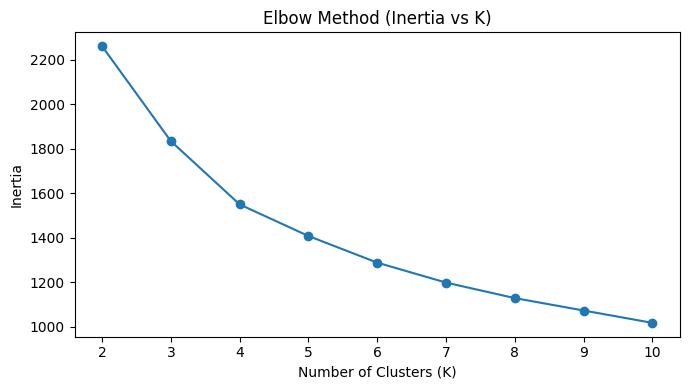

In [30]:
plt.figure(figsize=(7,4))
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method (Inertia vs K)")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.tight_layout()
plt.savefig('data/elbow_method.png')
plt.show()

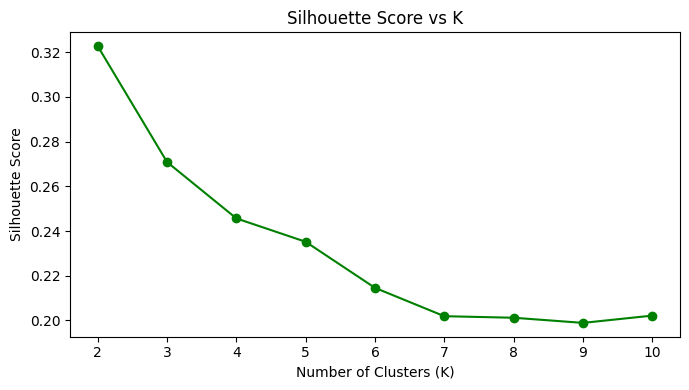

In [31]:
plt.figure(figsize=(7,4))
plt.plot(K_range, sil_scores, marker='o', color='green')
plt.title("Silhouette Score vs K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.tight_layout()
plt.savefig('data/silhouette_score.png')
plt.show()

In [32]:
best_k = K_range[np.argmax(sil_scores)]
print(f"\nBest K selected based on silhouette: {best_k}")


Best K selected based on silhouette: 2


In [33]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=50)
df_out['cluster'] = kmeans.fit_predict(X_scaled)
centers = kmeans.cluster_centers_

In [34]:
final_sil = silhouette_score(X_scaled, df_out['cluster'])
print(f"\nSilhouette score (K={best_k}): {final_sil:.4f}")


Silhouette score (K=2): 0.3227


In [35]:
centroids = scaler.inverse_transform(centers)
centroid_df = pd.DataFrame(centroids, columns=features)
print("\n Cluster Centroids (Original Scale):")
print(centroid_df)


 Cluster Centroids (Original Scale):
         age  cholesterol    systolic  diastolic
0  38.234756   192.185061  121.804878  77.356707
1  54.106643   219.739510  145.629371  92.288462


In [36]:
print("\n Cluster Mean Summary:")
cluster_mean = df_out.groupby('cluster')[features].mean()
print(cluster_mean)


 Cluster Mean Summary:
               age  cholesterol    systolic  diastolic
cluster                                               
0        38.234756   192.185061  121.804878  77.356707
1        54.106643   219.739510  145.629371  92.288462


In [37]:
print("\n CLUSTER INTERPRETATION (What each cluster represents):\n")

for i in range(best_k):
    cluster_data = df_out[df_out['cluster'] == i]
    print(f"\n Cluster {i}")
    print(f"Size: {len(cluster_data)} patients")
    print("\nFeature Averages:")
    print(cluster_data[features].mean())
    print("\nMost common condition:")
    print(cluster_data['condition'].value_counts().head(3))
    print("\nMost common medication:")
    print(cluster_data['medication'].value_counts().head(3))
    print("-" * 50)


 CLUSTER INTERPRETATION (What each cluster represents):


 Cluster 0
Size: 328 patients

Feature Averages:
age             38.234756
cholesterol    192.185061
systolic       121.804878
diastolic       77.356707
dtype: float64

Most common condition:
condition
Asthma          219
Diabetes         89
Hypertension     14
Name: count, dtype: int64

Most common medication:
medication
NONE         127
ALBUTEROL    100
METFORMIN     46
Name: count, dtype: int64
--------------------------------------------------

 Cluster 1
Size: 572 patients

Feature Averages:
age             54.106643
cholesterol    219.739510
systolic       145.629371
diastolic       92.288462
dtype: float64

Most common condition:
condition
Heart Disease    220
Hypertension     211
Diabetes         135
Name: count, dtype: int64

Most common medication:
medication
LISINOPRIL      233
ATORVASTATIN    171
NONE             97
Name: count, dtype: int64
--------------------------------------------------


## DBSCAN Clustering

In [38]:
# PCA — 2D for VISUALISATION only (not for DBSCAN input)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Project KMeans centroids into PCA space for comparison plot
centers_pca = pca.transform(centers)

Auto-detected elbow index : 784
Auto-detected eps value   : 1.0105


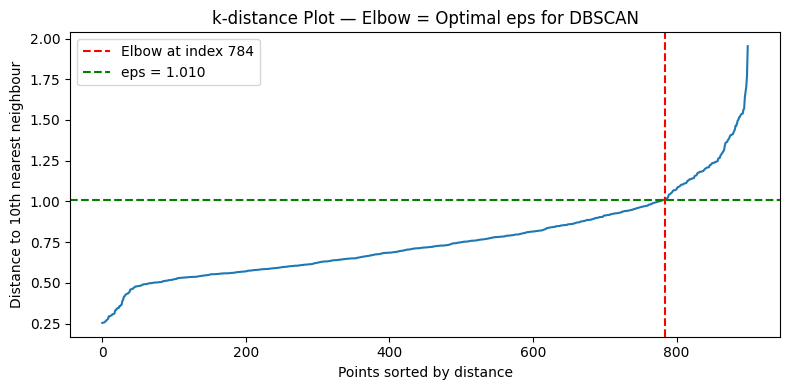

In [39]:
# k-distance plot for DBSCAN eps selection
# Uses a robust 'maximum curvature' (kneepoint) method instead of
# the fragile second-derivative argmax, which tends to fire too early
# on smooth curves and produce an oversized eps → single cluster.

nbrs = NearestNeighbors(n_neighbors=10).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
distances = np.sort(distances[:, -1])

# Robust kneepoint: normalise curve to [0,1]×[0,1] then find the point
# with maximum perpendicular distance from the diagonal.
n = len(distances)
x_norm = np.linspace(0, 1, n)
y_norm = (distances - distances.min()) / (distances.max() - distances.min())
# Vector from start to end of normalised curve
diff = np.array([x_norm[-1] - x_norm[0], y_norm[-1] - y_norm[0]])
diff_norm = diff / np.linalg.norm(diff)
# Perpendicular distance of each point from that line
vecs = np.column_stack([x_norm - x_norm[0], y_norm - y_norm[0]])
cross = np.abs(vecs[:, 0] * diff_norm[1] - vecs[:, 1] * diff_norm[0])
elbow_idx = int(np.argmax(cross))
auto_eps  = float(distances[elbow_idx])

print(f"Auto-detected elbow index : {elbow_idx}")
print(f"Auto-detected eps value   : {auto_eps:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(distances, linewidth=1.5)
plt.axvline(x=elbow_idx, color='red',  linestyle='--', label=f'Elbow at index {elbow_idx}')
plt.axhline(y=auto_eps,  color='green', linestyle='--', label=f'eps = {auto_eps:.3f}')
plt.title("k-distance Plot — Elbow = Optimal eps for DBSCAN")
plt.xlabel("Points sorted by distance")
plt.ylabel("Distance to 10th nearest neighbour")
plt.legend()
plt.tight_layout()
plt.savefig('data/kdistance_plot.png')
plt.show()


In [40]:
db = DBSCAN(eps=auto_eps, min_samples=13)
db_clusters = db.fit_predict(X_scaled)

n_clusters = len(set(db_clusters)) - (1 if -1 in db_clusters else 0)
n_noise    = sum(db_clusters == -1)

print(f"DBSCAN (eps={auto_eps:.3f}, min_samples=13):")
print(f"  Clusters found : {n_clusters}")
print(f"  Noise points   : {n_noise}")

# Silhouette score only valid with ≥2 clusters and at least one non-noise point
db_mask = db_clusters != -1
if n_clusters >= 2 and db_mask.sum() > 0:
    db_sil = silhouette_score(X_scaled[db_mask], db_clusters[db_mask])
    print(f"  Silhouette score (non-noise points): {db_sil:.4f}")
else:
    db_sil = None

if n_clusters <= 1:
    print("\n⚠  NOTE: DBSCAN found 0–1 cluster(s).")
    print("   This is a DATA issue, not a code issue.")
    print("   Your 4 features likely form one continuous density blob with no clear gaps.")
    print("   DBSCAN is not well-suited for this dataset — KMeans results are more reliable.")
    print(f"   (Tried eps={auto_eps:.3f} via robust kneepoint method; adjust manually if needed.)")


DBSCAN (eps=1.010, min_samples=13):
  Clusters found : 1
  Noise points   : 38

⚠  NOTE: DBSCAN found 0–1 cluster(s).
   This is a DATA issue, not a code issue.
   Your 4 features likely form one continuous density blob with no clear gaps.
   DBSCAN is not well-suited for this dataset — KMeans results are more reliable.
   (Tried eps=1.010 via robust kneepoint method; adjust manually if needed.)


## DBSCAN vs KMeans Comparison

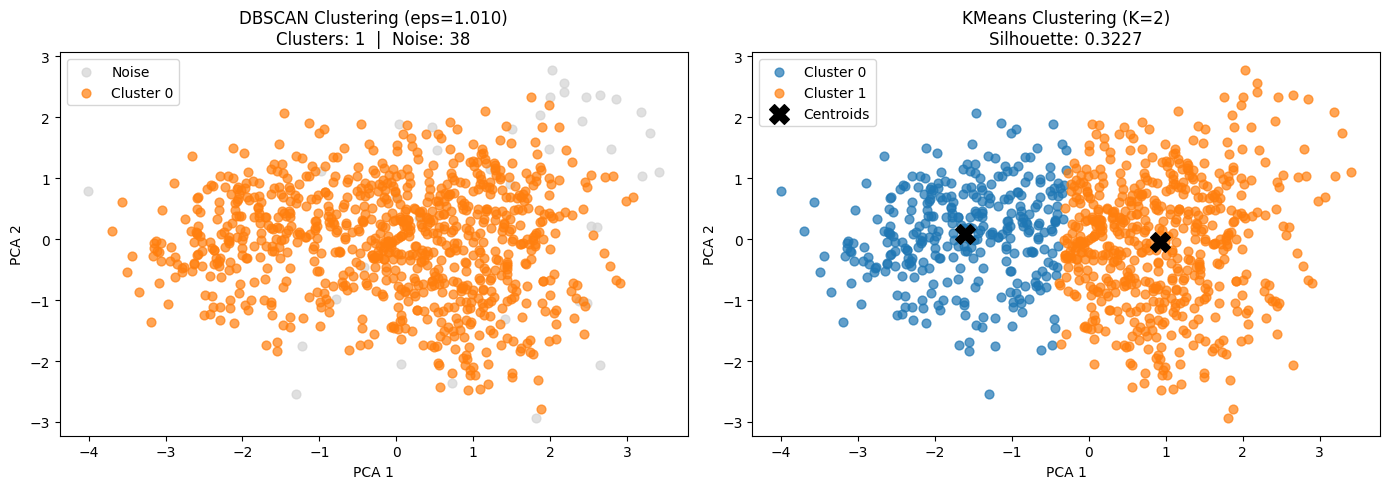

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- DBSCAN plot ---
unique_clusters = sorted(set(db_clusters))
tab_colors = plt.cm.tab10.colors

for i, cid in enumerate(unique_clusters):
    mask  = db_clusters == cid
    label = 'Noise' if cid == -1 else f'Cluster {cid}'
    color = 'lightgray' if cid == -1 else tab_colors[i % len(tab_colors)]
    axes[0].scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        color=color, label=label, s=40, alpha=0.7
    )

axes[0].set_title(f'DBSCAN Clustering (eps={auto_eps:.3f})\n'
                  f'Clusters: {n_clusters}  |  Noise: {n_noise}')
axes[0].set_xlabel('PCA 1')
axes[0].set_ylabel('PCA 2')
axes[0].legend()

# --- KMeans plot ---
colors = cm.tab10(range(best_k))

for i in range(best_k):
    mask = df_out['cluster'] == i
    axes[1].scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=[colors[i]], label=f'Cluster {i}', s=40, alpha=0.7
    )

axes[1].scatter(
    centers_pca[:, 0], centers_pca[:, 1],
    color='black', marker='X', s=200, zorder=5, label='Centroids'
)

axes[1].set_title(f'KMeans Clustering (K={best_k})\nSilhouette: {final_sil:.4f}')
axes[1].set_xlabel('PCA 1')
axes[1].set_ylabel('PCA 2')
axes[1].legend()

plt.tight_layout()
# FIX 4: Fixed filename typo comparision -> comparison
plt.savefig('data/clustering_comparison.png')
plt.show()